# CH03_측정

---
## 3.1 전쟁기간 중 민간인 희생자 측정
---

```
LYALL, J., BLAIR, G., & IMAI, K. (2013). Explaining Support for Combatants during Wartime: A Survey Experiment in Afghanistan. American Political Science Review, 107(4), 679–705.
doi:10.1017/S0003055413000403

Blair, G., Imai, K. and Lyall, J. (2014), Comparing and Combining List and Endorsement Experiments: Evidence from Afghanistan. American Journal of Political Science, 58: 1043-1063.
https://doi.org/10.1111/ajps.12086

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [4]:
os.chdir('/home/user/repo/studies/qss/data')

In [5]:
afghan = pd.read_csv('afghan.csv')
afghan.head()

,province,district,village.id,age,educ.years,employed,income,violent.exp.ISAF,violent.exp.taliban,list.group,list.response
0,Logar,Baraki Barak,80,26,10,0,"2,001-10,000",0.0,0.0,control,0
1,Logar,Baraki Barak,80,49,3,1,"2,001-10,000",0.0,0.0,control,1
2,Logar,Baraki Barak,80,60,0,1,"2,001-10,000",1.0,0.0,control,1
3,Logar,Baraki Barak,80,34,14,1,"2,001-10,000",0.0,0.0,ISAF,3
4,Logar,Baraki Barak,80,21,12,1,"2,001-10,000",0.0,0.0,ISAF,3


In [6]:
afghan.describe().round(2)

,village.id,age,educ.years,employed,violent.exp.ISAF,violent.exp.taliban,list.response
count,2754.00,2754.00,2754.00,2754.00,2729.00,2700.00,2754.00
mean,103.62,32.39,4.00,0.58,0.37,0.33,1.61
std,58.92,12.29,4.75,0.49,0.48,0.47,0.99
min,1.00,15.00,0.00,0.00,0.00,0.00,0.00
25%,53.00,22.00,0.00,0.00,0.00,0.00,1.00
50%,104.50,30.00,1.00,1.00,0.00,0.00,2.00
75%,153.00,40.00,8.00,1.00,1.00,1.00,2.00
max,204.00,80.00,18.00,1.00,1.00,1.00,4.00


In [8]:
afghan['income'] = afghan['income'].astype('category').cat.reorder_categories(
    ['less than 2,000', '2,001-10,000', '10,001-20,000', '20,001-30,000', 
     'over 30,000']
)

In [9]:
afghan['income'].value_counts(sort=False, dropna=False)

income
less than 2,000     457
2,001-10,000       1420
10,001-20,000       616
20,001-30,000        93
over 30,000          14
NaN                 154
Name: count, dtype: int64

In [11]:
pd.crosstab(afghan['violent.exp.ISAF'], afghan['violent.exp.taliban'], 
            rownames=['ISAF'], colnames=['Taliban'] ,normalize=True)

Taliban,0.0,1.0
ISAF,,
0.0,0.495345,0.131844
1.0,0.176909,0.195903


---
## 3.2 결측값 다루기
---

In [12]:
afghan['income'].head(10)

0     2,001-10,000
1     2,001-10,000
2     2,001-10,000
3     2,001-10,000
4     2,001-10,000
5              NaN
6    10,001-20,000
7     2,001-10,000
8     2,001-10,000
9              NaN
Name: income, dtype: category
Categories (5, str): ['less than 2,000', '2,001-10,000', '10,001-20,000', '20,001-30,000', 'over 30,000']

In [15]:
afghan['income'].isna().head(10)

0    False
1    False
2    False
3    False
4    False
5     True
6    False
7    False
8    False
9     True
Name: income, dtype: bool

In [16]:
afghan['income'].isnull().sum()

np.int64(154)

In [17]:
afghan['income'].isnull().mean()

np.float64(0.05591866376180102)

In [18]:
x = pd.Series([1,2,3,np.nan])

x.mean()

np.float64(2.0)

In [19]:
x.mean(skipna=False)

np.float64(nan)

In [20]:
pd.crosstab(afghan['violent.exp.ISAF'].fillna('Nonresponse'),
            afghan['violent.exp.taliban'].fillna('Nonresponse'),
            rownames=['ISAF'], colnames=['Taliban'], normalize=True)

Taliban,0.0,1.0,Nonresponse
ISAF,,,
0.0,0.482934,0.128540,0.007988
1.0,0.172476,0.190995,0.007988
Nonresponse,0.002542,0.002905,0.003631


In [21]:
afghan_sub = afghan.dropna()

print(afghan.shape[0])
print(afghan_sub.shape[0])
print(afghan['income'].dropna().shape[0])

2754
2554
2600


---
## 3.3 일변량 분포 시각화
---

### 3.3.1 막대 그래프

In [23]:
ISAF_ptable = (afghan['violent.exp.ISAF'].value_counts(normalize=True, dropna=False).reset_index())
ISAF_ptable

,violent.exp.ISAF,proportion
0,0.0,0.619463
1,1.0,0.371460
2,NaN,0.009078


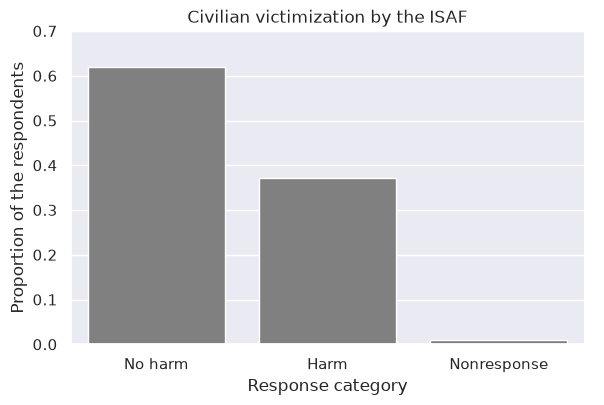

In [28]:
ISAF_ptable['response'] = ['No harm', 'Harm', 'Nonresponse']

sns.catplot(
    data=ISAF_ptable, x='response', y='proportion', color='gray',
    kind='bar', estimator=sum, height=4, aspect=1.5
).set(title='Civilian victimization by the ISAF',
      xlabel='Response category', ylabel='Proportion of the respondents',
      ylim=(0, 0.7));

In [29]:
Taliban_ptalbe = (afghan['violent.exp.taliban'].value_counts(normalize=True, dropna=False).reset_index())
Taliban_ptalbe

,violent.exp.taliban,proportion
0,0.0,0.657952
1,1.0,0.322440
2,NaN,0.019608


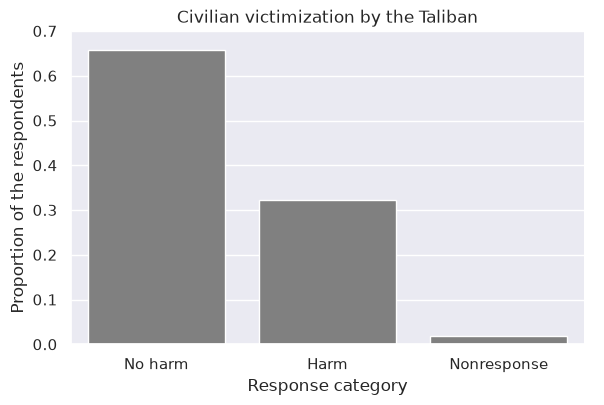

In [30]:
Taliban_ptalbe['response'] = ['No harm', 'Harm', 'Nonresponse']

sns.catplot(
    data=Taliban_ptalbe, x='response', y='proportion', color='gray',
    kind='bar', estimator=sum, height=4, aspect=1.5,
).set(title='Civilian victimization by the Taliban',
      xlabel='Response category', ylabel='Proportion of the respondents',
      ylim=(0, 0.7));

### 3.3.2 히스토그램

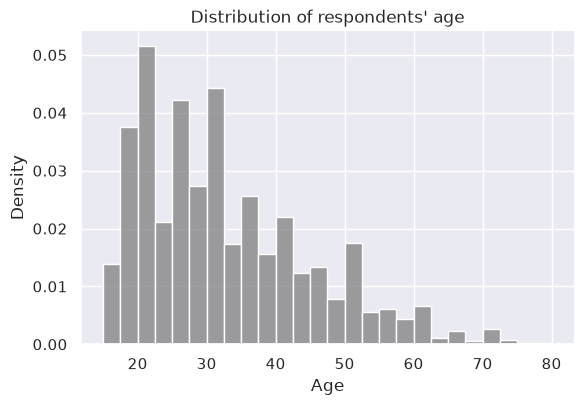

In [41]:
sns.displot(
    data=afghan, x='age', stat='density', color='gray',
    height=4, aspect=1.5
).set(title="Distribution of respondents' age", xlabel='Age');

Text(1.5, 0.5, 'median')

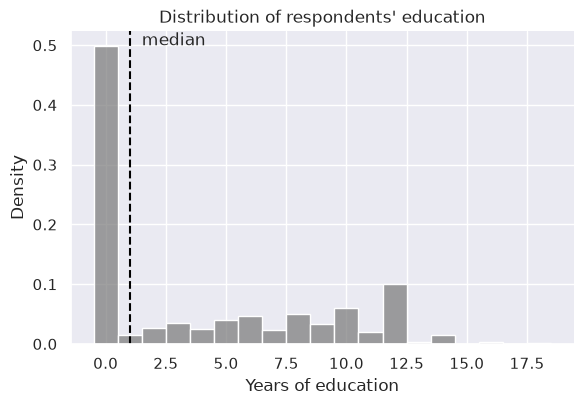

In [42]:
sns.displot(
    data=afghan, x='educ.years', stat='density', color='gray',
    binrange=(-0.5, 18.5), binwidth=1, height=4, aspect=1.5
).set(title="Distribution of respondents' education",
      xlabel='Years of education')

plt.axvline(x=afghan['educ.years'].median(), color='black', linestyle='--')

plt.text(x=1.5, y=.5, s='median')

### 3.3.3 박스 플롯

<Axes: ylabel='age'>

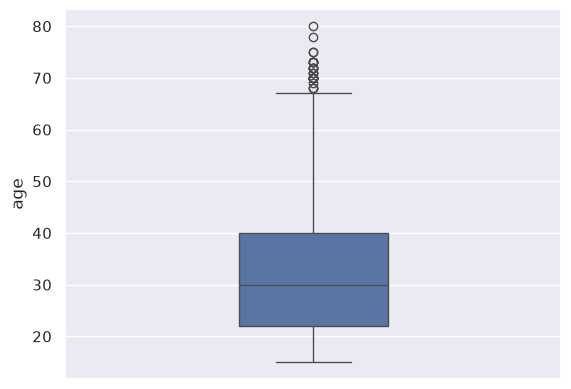

In [56]:
sns.boxplot(data=afghan['age'], width=.3)

In [44]:
afghan['province'] = afghan.province.astype('category')
afghan['province'].cat.categories

Index(['Helmand', 'Khost', 'Kunar', 'Logar', 'Uruzgan'], dtype='str')

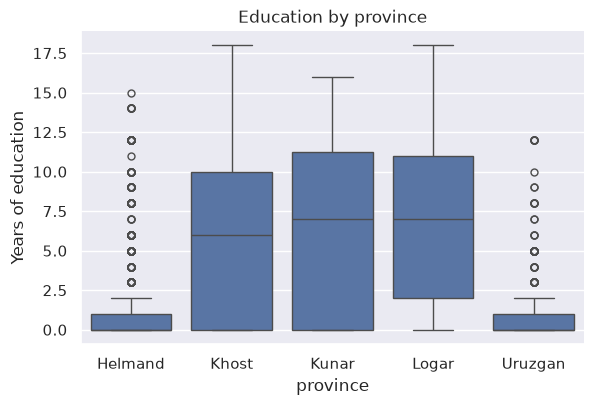

In [47]:
sns.catplot(
    data=afghan, x='province', y='educ.years', kind='box', height=4, aspect=1.5 
).set(title='Education by province', ylabel='Years of education');

In [58]:
afghan.groupby('province')['violent.exp.taliban'].mean()

province
Helmand    0.504222
Khost      0.233227
Kunar      0.303030
Logar      0.080247
Uruzgan    0.454545
Name: violent.exp.taliban, dtype: float64

In [59]:
afghan.groupby('province')['violent.exp.ISAF'].mean()

province
Helmand    0.541023
Khost      0.242424
Kunar      0.398990
Logar      0.144033
Uruzgan    0.496042
Name: violent.exp.ISAF, dtype: float64

In [65]:
sns.catplot(
    data=afghan, x='province', y='educ.years', kind='box', color='gray',
    height=4, aspect=1.5
).set(title='Education by province', xlabel='', ylabel='Years of education');

plt.savefig('education-by-province.png', bbox_inches='tight')

plt.close()

---
## 3.4 설문조사 샘플링
---

### 3.4.1 무작위화의 역할

In [66]:
afghan_village = pd.read_csv('afghan-village.csv')

In [75]:
afghan_village.head()

,altitude,population,village.surveyed
0,1959.0800,197,1
1,2425.8799,744,0
2,2236.6001,179,1
3,1691.7600,225,0
4,1928.0400,379,0


In [78]:
afghan_village['village_surveyed_desc'] = (
    np.where(afghan_village['village.surveyed']==1, 'Sampled', 'Nonsampled')
)

afghan_village['village_surveyed_desc'].head()

0       Sampled
1    Nonsampled
2       Sampled
3    Nonsampled
4    Nonsampled
Name: village_surveyed_desc, dtype: str

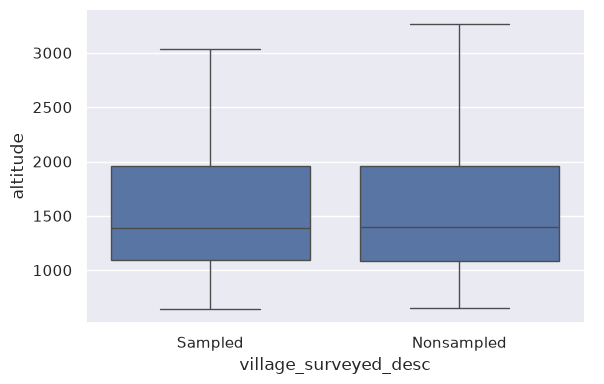

In [83]:
sns.catplot(
    data=afghan_village, x='village_surveyed_desc', y='altitude', kind='box',
    height=4, aspect=1.5
);

In [84]:
afghan_village['log_pop'] = np.log(afghan_village['population'])

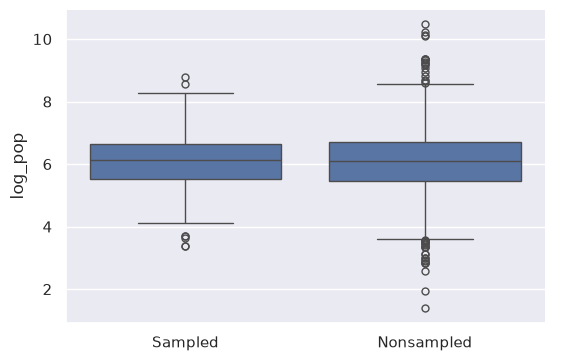

In [86]:
sns.catplot(
    data=afghan_village, x='village_surveyed_desc', y='log_pop', kind='box',
    height=4, aspect=1.4
).set(xlabel='')

### 3.4.2 무응답과 다른 편향 발생 요인

In [96]:
afghan.groupby('province')['violent.exp.taliban'].apply(lambda x: x.isnull().mean())

province
Helmand    0.030409
Khost      0.006349
Kunar      0.000000
Logar      0.000000
Uruzgan    0.062016
Name: violent.exp.taliban, dtype: float64

In [97]:
afghan.groupby('province')['violent.exp.ISAF'].apply(lambda x: x.isnull().mean())

province
Helmand    0.016374
Khost      0.004762
Kunar      0.000000
Logar      0.000000
Uruzgan    0.020672
Name: violent.exp.ISAF, dtype: float64

In [99]:
afghan.loc[afghan['list.group'] == 'ISAF', 'list.response'].mean() - afghan.loc[afghan['list.group'] == 'control', 'list.response'].mean()

np.float64(0.0490196078431373)

In [102]:
afghan.loc[afghan['list.group'] == 'taliban', 'list.response'].mean() - afghan.loc[afghan['list.group'] == 'control', 'list.response'].mean()

np.float64(0.224400871459695)

In [103]:
afghan['list.group'] = afghan['list.group'].astype('category').cat.reorder_categories(['control', 'ISAF', 'taliban'])

In [104]:
pd.crosstab(afghan['list.response'], afghan['list.group'],
            colnames=['group'], rownames=['response'])

group,control,ISAF,taliban
response,,,
0,188,174,0
1,265,278,433
2,265,260,287
3,200,182,198
4,0,24,0


---
## 3.5 정치적 양극화 측정하기
---